#INTRODUCCIÓN A LA CIENCIA DE DATOS ESPACIALES_EVALUACIÓN 1



**Diego Eduardo Monja Zagaceta - 20242642**

# Lectura de Datos

In [55]:
#Importamos las librerías para GPD y PD
import geopandas as gpd
import pandas as pd

#Conectamos el GitHub con el código
linkGit = 'https://github.com/DiegoMonja/ICDE_EVALUACION_1/raw/main/'

linkCSV = linkGit + 'some_dataworld.csv'
linkGPKG = linkGit + 'worldMaps.gpkg'

In [56]:
#Revisamos las capas del GeoPackage
gpd.list_layers(linkGPKG)

,name,geometry_type
0,rivers,MultiLineString
1,cities,Point
2,countries,MultiPolygon


In [57]:
#Tomamos específicamente la capa countries y vericamos que se haya realizado ello
countries = gpd.read_file(linkGPKG, layer='countries')
countries.head()

,COUNTRY,geometry
0,Aruba (Netherlands),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,Antigua and Barbuda,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,Afghanistan,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,Algeria,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,Azerbaijan,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."


In [58]:
#Leemos y comprobamos el CSV
someData = pd.read_csv(linkCSV)
someData.head()

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
1,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,ANGOLA,AO,AGO,AFRICA,87.8,19362000,1246700,107,37202061,25700000
4,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000


In [60]:
#Como se puede observar, la columna de países de los datos tienen diferentes nombres, por lo que para unir los documentos, el título de la columna debe ser iguales
countries.rename(columns={'COUNTRY':'Country'}, inplace=True)
countries.columns

Index(['Country', 'geometry'], dtype='object')

In [8]:
#Por otro lado, los nombres en los datos de countries están en minúscula, por lo que debemos cambiarlos también
countries['Country'] = countries.Country.str.upper()
countries.head()

,Country,geometry
0,ARUBA (NETHERLANDS),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,ANTIGUA AND BARBUDA,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,AFGHANISTAN,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,ALGERIA,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,AZERBAIJAN,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."


*Pre procesamiento: Merging*

In [64]:
#Ahora bien, debemos revisar que la mayor cantidad de datos se encuentren en ambos docuementos para la unión
#Pues, existen países que si se encuentran pero tiene un nombre minimamente diferente pero que el sistema no puede reconocerlos
#Por lo tanto, definimos los países que solo están supuestamente en cada conjunto de datos
onlyDF = set(someData.Country) - set(countries.Country)
onlyGDF = set(countries.Country) - set(someData.Country)
print("Solo en someData:", onlyDF)
print("Solo en countries:", onlyGDF)

Solo en someData: {'BELGIUM', 'ARMENIA', 'SWEDEN', 'VIETNAM', 'AUSTRIA', 'MALDIVES', 'ESTONIA', 'LITHUANIA', 'CYPRUS', 'TIMOR-LESTE', 'INDIA', 'KENYA', 'LIBYA', 'SOLOMON ISLANDS', 'SUDAN (THE)', 'MOROCCO', 'OMAN', 'HONDURAS', 'ROMANIA', 'BAHAMAS (THE)', 'UKRAINE', 'PHILIPPINES (THE)', 'CROATIA', 'GUINEA', 'THAILAND', 'PANAMA', 'SWITZERLAND', 'LIBERIA', 'SLOVENIA', 'MEXICO', 'MALTA', 'TAJIKISTAN', 'MAURITIUS', 'EL SALVADOR', 'CENTRAL AFRICAN REPUBLIC (THE)', 'FINLAND', 'DOMINICAN REPUBLIC (THE)', 'SAUDI ARABIA', 'ANGOLA', 'DJIBOUTI', 'UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)', 'KAZAKHSTAN', 'NEW ZEALAND', 'TRINIDAD AND TOBAGO', 'TURKEY', 'GERMANY', 'MICRONESIA (FEDERATED STATES OF)', 'ETHIOPIA', 'AFGHANISTAN', 'MONTENEGRO', 'GUATEMALA', 'MALAWI', 'NEPAL', 'BELIZE', 'SPAIN', "CÔTE D'IVOIRE", 'SIERRA LEONE', 'URUGUAY', 'CONGO (THE DEMOCRATIC REPUBLIC OF THE)', 'GAMBIA (THE)', 'FRANCE', 'JORDAN', 'BELARUS', 'AZERBAIJAN', 'CONGO (THE)', 'BOTSWANA', 'COSTA RICA', 'AUSTRALIA

In [65]:
#Para ello, se usará la libreria thefuzz para comparar los nombres
!pip install thefuzz
#Se define la función para comparar los nombres
from thefuzz.process import extractOne as best
#Se muestran las coincidencias y su nivel de similitud
pd.DataFrame([(Country, best(Country,onlyGDF)[0],best(Country,onlyGDF)[1]) for Country in onlyDF]).sort_values(by=2)

,0,1,2
55,CÔTE D'IVOIRE,Israel,60
136,ESWATINI,India,68
70,CABO VERDE,Cape Verde,80
9,TIMOR-LESTE,East Timor,81
138,LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE),Dominican Republic,86
...,...,...,...
167,SENEGAL,Senegal,100
168,JAPAN,Japan,100
169,ECUADOR,Ecuador,100
170,SURINAME,Suriname,100


In [66]:
#Se crea un diccionario con las coincidencias de nombres
changesToDF = {country:best(country,onlyGDF)[0] for country in onlyDF}
changesToDF


{'BELGIUM': 'Belgium',
 'ARMENIA': 'Armenia',
 'SWEDEN': 'Sweden',
 'VIETNAM': 'Vietnam',
 'AUSTRIA': 'Austria',
 'MALDIVES': 'Maldives',
 'ESTONIA': 'Estonia',
 'LITHUANIA': 'Lithuania',
 'CYPRUS': 'Cyprus',
 'TIMOR-LESTE': 'East Timor',
 'INDIA': 'India',
 'KENYA': 'Kenya',
 'LIBYA': 'Libya',
 'SOLOMON ISLANDS': 'Solomon Islands',
 'SUDAN (THE)': 'Sudan',
 'MOROCCO': 'Morocco',
 'OMAN': 'Oman',
 'HONDURAS': 'Honduras',
 'ROMANIA': 'Romania',
 'BAHAMAS (THE)': 'Bahamas',
 'UKRAINE': 'Ukraine',
 'PHILIPPINES (THE)': 'Philippines',
 'CROATIA': 'Croatia',
 'GUINEA': 'Guinea',
 'THAILAND': 'Thailand',
 'PANAMA': 'Panama',
 'SWITZERLAND': 'Switzerland',
 'LIBERIA': 'Liberia',
 'SLOVENIA': 'Slovenia',
 'MEXICO': 'Mexico',
 'MALTA': 'Malta',
 'TAJIKISTAN': 'Tajikistan',
 'MAURITIUS': 'Mauritius',
 'EL SALVADOR': 'El Salvador',
 'CENTRAL AFRICAN REPUBLIC (THE)': 'Central African Republic',
 'FINLAND': 'Finland',
 'DOMINICAN REPUBLIC (THE)': 'Dominican Republic',
 'SAUDI ARABIA': 'Saudi Arabia

In [67]:
#Se remplaza los nombres para la mezcla
someData.replace(to_replace={'Country' :changesToDF},inplace=True)

In [69]:
#Se corrobora que no haya países sin normalizar en someData
onlyDF = set(someData.Country) - set(countries.Country)
onlyGDF = set(countries.Country) - set(someData.Country)
print("Solo en someData:", len(onlyDF))
print("Solo en countries:", len(onlyGDF))

Solo en someData: 0
Solo en countries: 83


In [70]:
#Unimos los datos
theMapAndData = countries.merge(someData, on='Country')
theMapAndData.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Country       172 non-null    object  
 1   geometry      172 non-null    geometry
 2   iso2          171 non-null    object  
 3   iso3          172 non-null    object  
 4   region        172 non-null    object  
 5   fragility     172 non-null    float64 
 6   co2           172 non-null    int64   
 7   sq_km         172 non-null    int64   
 8   num_airports  172 non-null    int64   
 9   population    172 non-null    int64   
 10  mobiles       172 non-null    int64   
dtypes: float64(1), geometry(1), int64(5), object(4)
memory usage: 14.9+ KB


In [71]:
#Guarda el GeoDatoFrame en un archivo
theMapAndData.to_file("IndicadoresMundiales.json")

# Gráfica DDM (Dot Density Map)

In [73]:
#Definimos la variable que almacena los datos de los países de América
America=theMapAndData[theMapAndData.region.isin([
    'SOUTH AMERICA',
    'CENTRAL AMERICA AND THE CARIBBEAN',
    'NORTH AMERICA'
])]

In [74]:
#Revisamos las unidades geográficas de los datos
America.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [22]:
America.crs.axis_info[0].unit_name, America.crs.axis_info[1].unit_name

('degree', 'degree')

In [23]:
America.crs.is_projected

False

<Axes: >

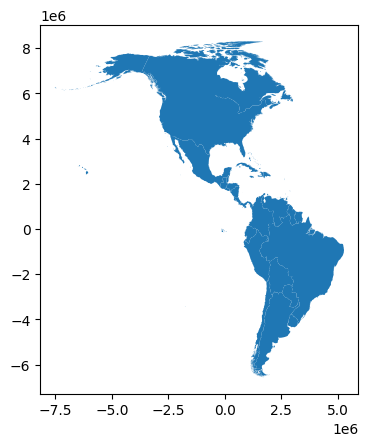

In [75]:
#Al observar que los datos no están proyectados, los proyectamos usando el dato dado por IA y graficamos para observar que sea el correcto
America_proj = America.to_crs(8858)
America_proj.plot()

In [76]:
#Verificamos que las unidades de proyección sean las correctas
America.to_crs(8858).crs.axis_info[0].unit_name, America.to_crs(8858).crs.axis_info[1].unit_name

('metre', 'metre')

In [78]:
#Guardamos una copia del original para almacenar los datos de la gráfica DDM
justDots=America_proj.copy()
#Definimos cuánto representa cada punto
dot_value = 100000
#Se calcula el número de puntos por país
justDots['num_dots'] = (justDots['mobiles'] / dot_value).astype(int)

In [82]:
#Se genera y se separa los puntos dentro de cada país
justDots = justDots.sample_points(size=justDots['num_dots']).explode(index_parts=True)

In [86]:
#Reiniciamos el índice de los puntos
justDots.reset_index(drop=True, inplace=True)
#Creamos el GeoDataFrame con los puntos del DDM
America_dots=gpd.GeoDataFrame(geometry=justDots)
#Se muestran los puntos generados
America_dots

,geometry
0,POINT (2636984.704 2181165.031)
1,POINT (2499204.069 -4132372.807)
2,POINT (2376460.128 -3549906.881)
3,POINT (2768899.352 -3320918.762)
4,POINT (2686746.326 -4431674.36)
...,...
11503,POINT (2660842.704 625092.287)
11504,POINT (2679041.843 799322.906)
11505,POINT (2430074.575 1201375.031)
11506,POINT (2439905.159 412197.58)


In [88]:
#Nos aseguramos que los puntos estén en la misma proyección que el mapa
America_dots = America_dots.to_crs(8858)

<Axes: >

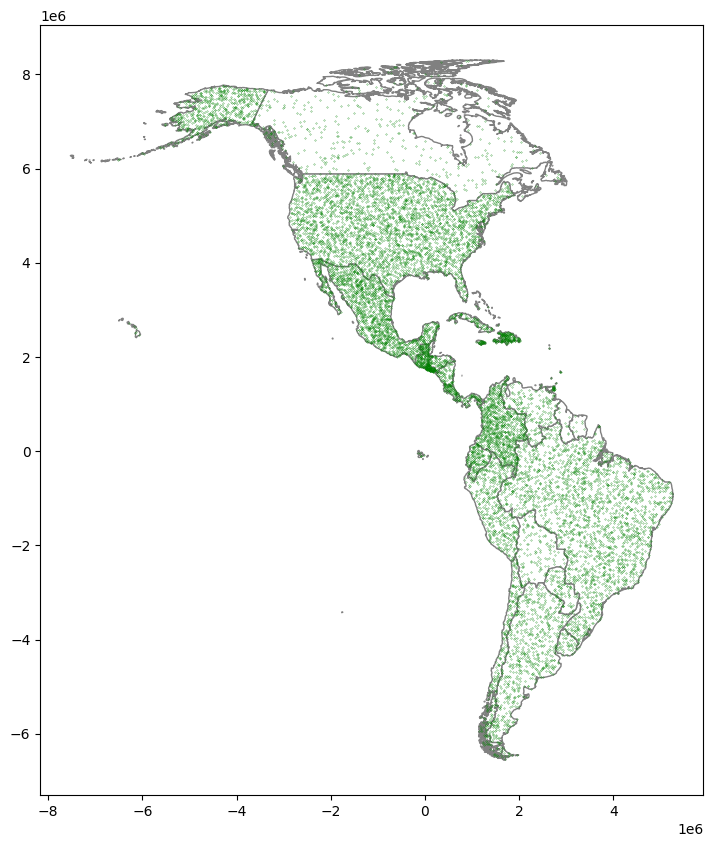

In [89]:
#Se crea el mapa base de América
base=America_proj.plot(facecolor="white",
                      edgecolor='grey', figsize=(10,10))
#Agrega los puntos del DDM sobre el mapa
America_dots.plot(markersize=0.05, color='green', ax=base)

# Gráfica PSM (Proportional Symbol Map)

In [90]:
#Se crea una copia del mapa para el PSM
America_centroids = America_proj.copy()
#Se obtiene un punto representativo dentro de cada país
America_centroids['geometry']=America_proj.representative_point()
#Se calcula el tamaño de los símbolos según los usuarios móviles
America_centroids['size'] = America_centroids['mobiles'].apply(lambda x: x**0.5/100)

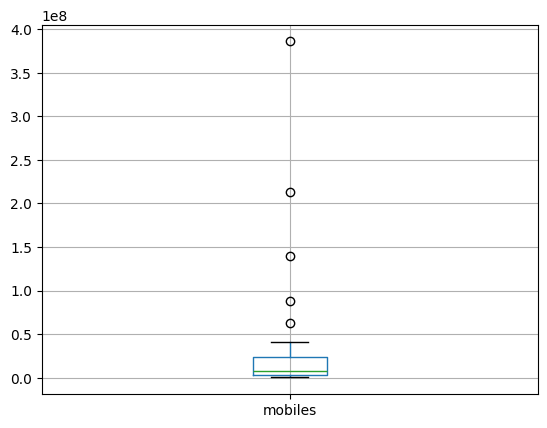

In [91]:
#Identificamos posible valores atípicos en los usuarios móviles
boxplotInfo=America_centroids.boxplot(column='mobiles',return_type="dict")

In [92]:
#Se extrae los valores que el boxplot identificó como outliers
outliers=boxplotInfo['fliers'][0].get_ydata()
outliers

array([62700000, 213000000, 87400000, 140000000, 386000000], dtype=object)

In [94]:
#Identificamos los países con valores atípicos
America_centroids[America_centroids.mobiles.isin(outliers)]

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,size,mobiles_outliers
8,Argentina,POINT (2265962.186 -4493827.822),AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,79.183332,1
23,Brazil,POINT (3803192.426 -1764170.762),BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,145.945195,1
38,Colombia,POINT (1675341.523 525486.665),CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,93.487967,1
110,Mexico,POINT (-1120447.446 2972427.316),MX,MEX,NORTH AMERICA,69.7,463739000,1964375,1580,130739927,140000000,118.321596,1
159,United States,POINT (-768981.361 4547618.41),US,USA,NORTH AMERICA,38.0,5144361000,9833517,16116,341963408,386000000,196.468827,1


In [93]:
#Se identifica los outliers con 1 y los demás con 0
America_centroids['mobiles_outliers']=America_centroids.mobiles.isin(outliers)*1
#Verificamos el GeoDataFrame actualizado
America_centroids

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,size,mobiles_outliers
0,Antigua and Barbuda,POINT (2646987.996 2176408.939),AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000,4.289522,0
8,Argentina,POINT (2265962.186 -4493827.822),AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,79.183332,1
12,Barbados,POINT (2878303.996 1688332.479),BB,BRB,CENTRAL AMERICA AND THE CARIBBEAN,48.0,1703000,430,1,304139,323000,5.683309,0
15,Bahamas,POINT (1545442.282 2682348.628),BS,BHS,CENTRAL AMERICA AND THE CARIBBEAN,48.8,3984000,13880,54,410862,400000,6.324555,0
17,Belize,POINT (119868.834 2194756.836),BZ,BLZ,CENTRAL AMERICA AND THE CARIBBEAN,62.5,541000,22966,27,415789,264000,5.138093,0
19,Bolivia,POINT (2392919.118 -2073238.575),BO,BOL,SOUTH AMERICA,72.9,17786000,1098581,201,12311974,12000000,34.641016,0
23,Brazil,POINT (3803192.426 -1764170.762),BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,145.945195,1
28,Canada,POINT (-1229013.274 6460418.072),CA,CAN,NORTH AMERICA,20.0,612084000,9984670,1459,38794813,36500000,60.415230,0
35,Chile,POINT (1655151.382 -4304799.911),CL,CHL,SOUTH AMERICA,38.9,88333000,756102,379,18664652,26700000,51.672043,0
38,Colombia,POINT (1675341.523 525486.665),CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,93.487967,1


In [37]:
#Separamos los países con valores atípicos y sin valores atípicos
America_centroids_out = America_centroids[America_centroids.mobiles_outliers==1].copy()
America_centroids_no_out = America_centroids[America_centroids.mobiles_outliers==0].copy()

In [38]:
#Calculamos el tamaño de los símbolos atípicos
America_centroids_out['size']=America_centroids_out['mobiles'].apply(lambda x: x**0.5/50)
America_centroids_no_out['size']=America_centroids_no_out['mobiles'].apply(lambda x: x**0.5/50)

<Axes: >

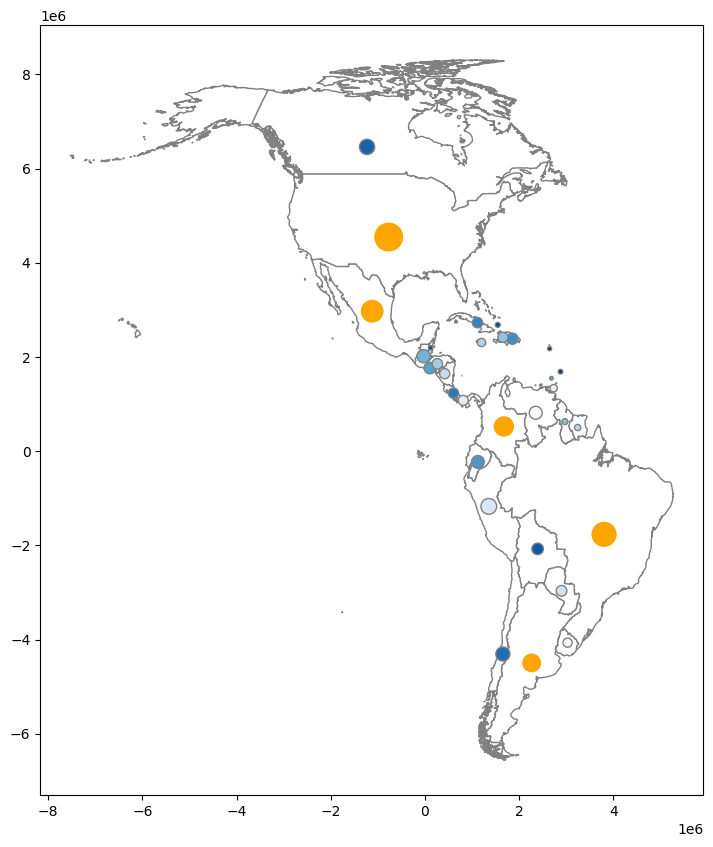

In [95]:
#Creamos el mapa base de América
base=America_proj.plot(color='white', edgecolor='grey', figsize=(10,10))
#Representa los países sin atípicos mediante símbolos con tamaño y colores proporcionales a la cantidad de teléfonos móviles en el país
America_centroids_no_out.plot(
    ax=base,
    markersize=America_centroids_no_out['size'],
    edgecolor='grey',
    c=America_centroids_no_out['size'],
    cmap='Blues_r')
#Representa los valores atípicos con símbolos de diferente tamaño pero con un color fijo
America_centroids_out.plot(
    ax=base,
    markersize=America_centroids_out['size'],
    color='orange')

# Gráfico Choropleth

In [112]:
#Si se desea verificar las versiones de las librerías
#! pip show numba mapclassify numpy

#Calcula la densidad de usuarios móviles, es decir, normalizamos los datos
America_proj['mobiles_density']=America_proj.mobiles/America_proj.sq_km

In [113]:
#Importamos las librerias necesarias
import mapclassify
import numpy as np

#Se fija la semilla para obtener resultados reproducibles
np.random.seed(12345)
#Consideramos 5 intervalos
K=5

#Se realiza el análisis de dispersión de los datos mediante diferentes modelos

#Se selecciona la variable a clasificar
theVar=America_proj['mobiles']
#Se clasifica por intervalos iguales
ei5 = mapclassify.EqualInterval(theVar, k=K)
#Se clasifica según desviaciones estándar
msd = mapclassify.StdMean(theVar)
#Se clasifica por cuantiles
q5 = mapclassify.Quantiles(theVar, k=K)
#Se clasifica por máximos quiebres
mb5 = mapclassify.MaximumBreaks(theVar, k=K)
#Se clasifica por quiebres cabeza-cola
ht = mapclassify.HeadTailBreaks(theVar)
#Se clasifica mediante Fisher-Jenks
fj5 = mapclassify.FisherJenks(theVar, k=K)
#Se clasifica mediante Jenks-Caspall
jc5 = mapclassify.JenksCaspall(theVar, k=K)
#Se clasifica mediante Max-P
mp5 = mapclassify.MaxP(theVar, k=K)


In [99]:
#Se agrupa los clasificadores
class5 = ei5, msd, q5, mb5, ht, fj5, jc5, mp5
#Obtenemos el ADCM de cada clasificador
fits = np.array([c.adcm for c in class5])
#Se crea un DataFrame con los valores ADCM
adcms = pd.DataFrame(fits)
#Se Agrega el nombre de cada clasificador
adcms['classifier'] = [c.name for c in class5]
#Se define los nombres de las columnas
adcms.columns = ['ADCM', 'Classifier']

<Axes: ylabel='Classifier'>

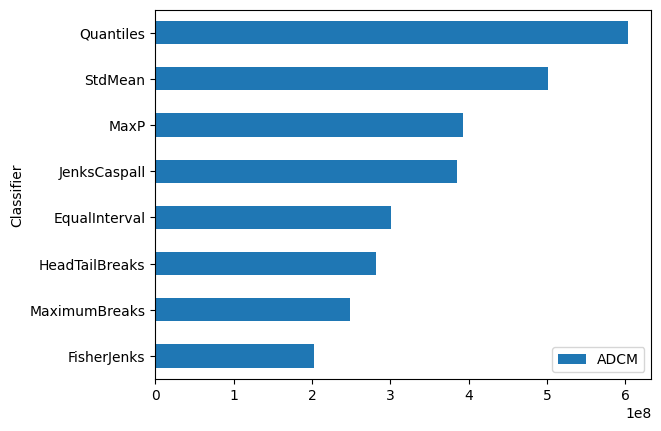

In [100]:
#Se compara los clasificadores según su ADCM
adcms.sort_values('ADCM').plot.barh(x='Classifier')

In [103]:
#Asigna a cada país la clase de Fisher-Jenks al tener menos ADCM
America_proj['mobiles_density_fj5'] = fj5.yb

In [106]:
#Se define las etiquetas para cada clase
newLabelsForLevels={0:"0_VeryLow", 1:"1_Low", 2:"2_Medium", 3:"3_High", 4:"4_VeryHigh"}
#Se remplazan los códigos por etiquetas
America_proj['mobiles_density_fj5_cat'] = America_proj.loc[:,'mobiles_density_fj5'].replace(newLabelsForLevels)
#Se verifica las clases asignadas
America_proj[['mobiles_density','mobiles_density_fj5','mobiles_density_fj5_cat']].head(20)

,mobiles_density,mobiles_density_fj5,mobiles_density_fj5_cat
0,415.349887,0,0_VeryLow
8,22.550712,1,1_Low
12,751.162791,0,0_VeryLow
15,28.818444,0,0_VeryLow
17,11.495254,0,0_VeryLow
19,10.923182,0,0_VeryLow
23,25.012418,3,3_High
28,3.655604,1,1_Low
35,35.312696,0,0_VeryLow
38,76.740041,1,1_Low


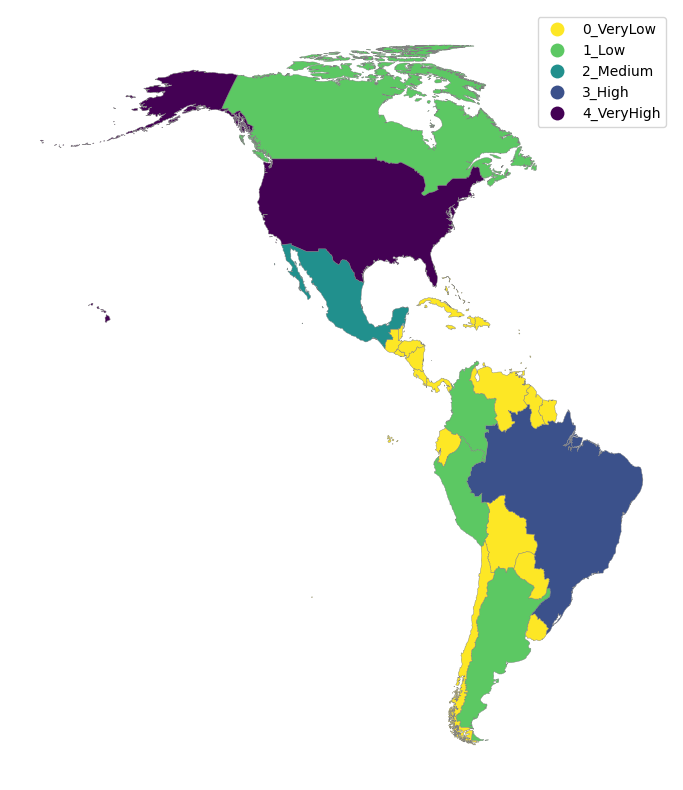

In [107]:
#Se importa las librerias necesarias
import matplotlib.pyplot as plt
#Se crea el área para el mapa
f, ax = plt.subplots(1, figsize=(10,10))
#Representa la densidad de usuarios móviles por categorías
America_proj.plot(column='mobiles_density_fj5_cat',
                  cmap='viridis_r',
                  categorical=True,
                  edgecolor='grey',
                  linewidth=0.3,
                  legend=True,
                  ax=ax)
#Se ocultan los ejes
ax.set_axis_off()

In [109]:
#Se identifica los GeoDataFrames en la memoria
geodataframe_list = [var for var in globals() if isinstance(globals()[var], gpd.GeoDataFrame)]
print("List of GeoDataFrames in memory:")
for name in geodataframe_list:
  print(name)

List of GeoDataFrames in memory:
countries
_5
_8
theMapAndData
America
America_proj
America_dots
_28
America_centroids
_35
_36
America_centroids_out
America_centroids_no_out
_57
_83
_85
_86
_93
_94


In [108]:
#Se guardan los resultados en un mismo GeoPackage
America_proj.to_file("america_mobiles.gpkg",driver='GPKG', layer='continent')
America_dots.to_file("america_mobiles.gpkg",driver='GPKG', layer='mobiles_ddm')
America_centroids.to_file("america_mobiles.gpkg",driver='GPKG', layer='mobiles_psm')
America_centroids_out.to_file("america_mobiles.gpkg",driver='GPKG', layer='outlier_mobiles_psm')
America_centroids_no_out.to_file("america_mobiles.gpkg",driver='GPKG', layer='no_outlier_mobiles_psm')